# Assignment: Logical Operations on a Color Image Using a Matrix Mask

## Objective
To apply pixel-wise logical operations between a color image and a secondary matrix mask.  
This simulates real-life tasks like highlighting regions, protecting parts of an image, or creating simple visual effects.

---

## Real-Life Scenario
You are working on a **product advertisement image**.  
You need to **highlight a specific region** (e.g., the product area) while **dimming the background**.  
You will use a manually defined matrix as a logical mask and apply **logical operations** to achieve this.

---

## Tasks

### 1️ Image Selection
- Load any **color image** (e.g., a fruit, a logo, or an object).

---

### 2️ Matrix Creation
- Define a **3×3** or **5×5** matrix that acts as a logical mask.  
- Expand this matrix over the image to form a mask.

#### Example 5×5 Mask (values are in 0 and 255):

In [ ]:
mask = [[255, 255, 255, 0, 0],
[255, 255, 255, 0, 0],
[255, 255, 255, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0]]

This mask covers only the **top-left region** of the image when repeated.

---

### 3️ Logical Operations
Apply the following operations between the **image** and the **expanded mask**:

- **AND** → Keeps only the highlighted region.  
- **OR** → Brightens or reveals the masked area.  
- **XOR** → Shows non-overlapping pixels.  
- **NOT** → Inverts the image colors.

---

### 4️ Display Results
Show the following images side by side in subplots:
- Original Image  
- Mask  
- Result of `AND` operation  
- Result of `OR` operation  
- Result of `XOR` operation  
- Result of `NOT` operation  

---

### 5️ Observation
Write **one line** explaining what each logical operation does to the image.

In [7]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread("image.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # Convert BGR → RGB

In [4]:
rows, cols, _ = img.shape

mask = np.zeros((rows, cols), dtype=np.uint8)
mask[0:rows//2, 0:cols//2] = 255      # top-left region becomes white (255)
mask_3 = cv2.merge([mask, mask, mask])

In [5]:
and_result = cv2.bitwise_and(img, mask_3)
or_result = cv2.bitwise_or(img, mask_3)
xor_result = cv2.bitwise_xor(img, mask_3)
not_result = cv2.bitwise_not(img)


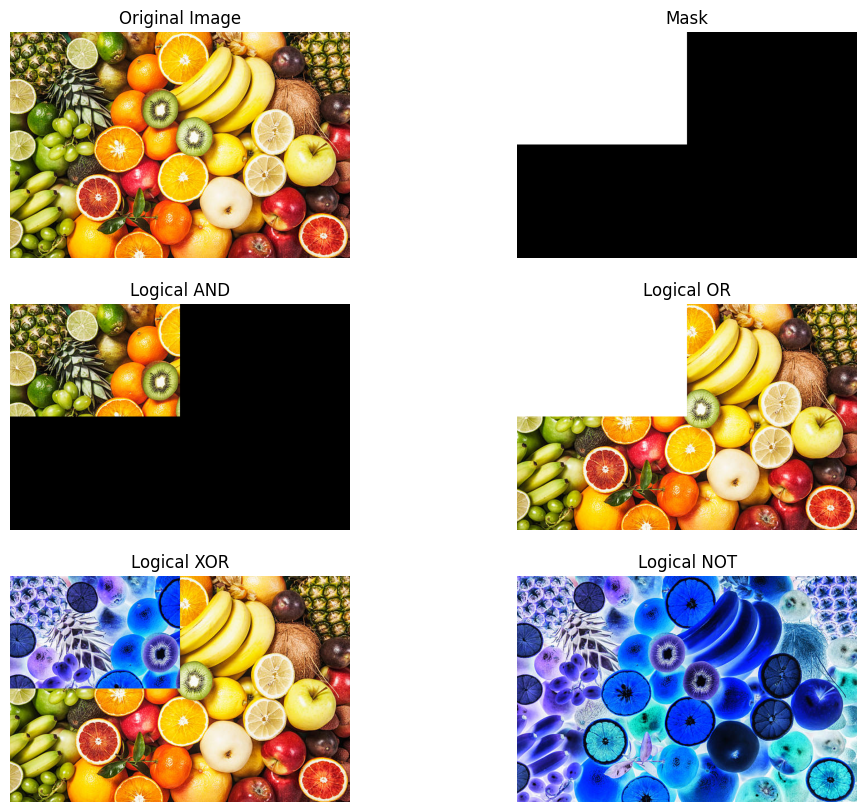

In [6]:
plt.figure(figsize=(12, 10))

plt.subplot(3, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(3, 2, 3)
plt.imshow(and_result)
plt.title("Logical AND")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(or_result)
plt.title("Logical OR")
plt.axis("off")

plt.subplot(3, 2, 5)
plt.imshow(xor_result)
plt.title("Logical XOR")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(not_result)
plt.title("Logical NOT")
plt.axis("off")

plt.show()

In [11]:
df = pd.DataFrame({
    "Operation": ['AND', 'OR', 'XOR', 'NOT'],
    "Effect on Image": ['Keeps only the masked region; other pixels become black', 'Highlights the masked area by making it bright', 'Shows difference between image and mask; masked region becomes bright', 'Inverts the entire image; produces negative effect']
})
df

,Operation,Effect on Image
0,AND,Keeps only the masked region; other pixels bec...
1,OR,Highlights the masked area by making it bright
2,XOR,Shows difference between image and mask; maske...
3,NOT,Inverts the entire image; produces negative ef...
